In [1]:
import arviz as az
import io
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from pathlib import Path
import pymc as pm
import pytensor.tensor as pt
import requests
import statsmodels.api as sm
import warnings
import xarray as xr

#seed = sum(map(ord, "PyMC LABS - BVAR"))
#rng = np.random.default_rng(seed=seed)

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    module="openpyxl.worksheet._reader",
)

In [2]:
def companion_eigs(A_draw):
    """
    A_draw: (p, K, K) with VAR form y_t = sum_{l=1}^p A_l y_{t-l} + ...
    Returns eigenvalues of the companion matrix.
    """
    p, K, _ = A_draw.shape
    C = np.zeros((K*p, K*p))
    C[:K, :K*p] = np.hstack([A_draw[l] for l in range(p)])
    if p > 1:
        C[K:, :-K] = np.eye(K*(p-1))
    return np.linalg.eigvals(C)

def irf_from_A(A_draw, shock_idx, horizons=40, shock_size=1.0):
    """
    A_draw: (p, K, K)
    shock_idx: index of shocked variable in vars_endog ordering
    horizons: number of steps ahead
    shock_size: size of shock applied to y_t at impact (in the same units as the standardized data)
    Returns: (horizons+1, K) IRF path.
    """
    p, K, _ = A_draw.shape

    # Companion matrix
    C = np.zeros((K*p, K*p))
    C[:K, :K*p] = np.hstack([A_draw[l] for l in range(p)])
    if p > 1:
        C[K:, :-K] = np.eye(K*(p-1))

    # Impact shock to current period
    state = np.zeros(K*p)
    state[shock_idx] = shock_size

    out = np.zeros((horizons+1, K))
    out[0] = state[:K]

    for h in range(1, horizons+1):
        state = C @ state
        out[h] = state[:K]

    return out

def companion_eigs(A_draw):
    """
    A_draw: (lags, K, K) with VAR form y_t = sum_{l=1}^p A_l y_{t-l} + ...
    returns eigenvalues of companion matrix
    """
    p, K, _ = A_draw.shape
    C = np.zeros((K*p, K*p))
    C[:K, :K*p] = np.hstack([A_draw[l] for l in range(p)])
    if p > 1:
        C[K:, :-K] = np.eye(K*(p-1))
    return np.linalg.eigvals(C)

In [3]:
data_path = Path(Path.cwd().parent / "data processed" / "nato_dataset.csv")
print("NATO dataset")
print("Full file path: ",data_path)
print("File exists: ",data_path.exists())

NATO dataset
Full file path:  /Users/awalters/Documents/GitHub/paper_replications_dec_2025/govt_spending/data processed/nato_dataset.csv
File exists:  True


In [4]:
df = pd.read_csv(data_path)
df = df.copy()
df = df.set_index("year")

In [5]:
countries_iso = ['BEL', 'CHE', 'DNK', 'ESP', 'FIN', 'FRA', 'GBR', 'ITA', 'NLD', 'NOR', 'PRT', 'SWE']
countries_names = ['Belgium', 'Switzerland', 'Denmark', 'Spain', 'Finland', 'France', 'United Kingdom', 'Italy', 'Netherlands', 'Norway', 'Portugal', 'Sweden']

Select country here:

In [6]:
country_iso = "FRA"
country_name = "France"

In [7]:
df = df.loc[df["iso"] == country_iso]

In [8]:
df

,iso,mil_delta,log_rgdp_pc,log_gov_pc,log_tfp,tbill,def_gdp,debt_gdp
year,,,,,,,,
1951,FRA,1.332682,-5.104917,-6.586382,1.074319,2.7000,-3.110687,33.8700
1952,FRA,1.241057,-5.073592,-6.480941,1.100461,3.7100,-5.144343,32.8700
1953,FRA,0.343609,-5.024529,-6.429608,1.139061,4.0400,-4.503882,35.0000
1954,FRA,-1.450743,-4.971793,-6.463302,1.186064,3.5900,-2.105428,34.3700
1955,FRA,-0.735951,-4.918610,-6.418756,1.234464,3.1600,-2.799819,33.2700
...,...,...,...,...,...,...,...,...
2016,FRA,-0.018015,-3.542763,-4.996208,2.511868,-0.3194,-3.676466,97.9568
2017,FRA,0.000591,-3.527809,-4.979738,2.529157,-0.3534,-3.245152,98.1321
2018,FRA,-0.006266,-3.520962,-5.006632,2.532954,-0.3629,-2.900386,97.7815


In [9]:
vars_endog = [
    "mil_delta", #defense spending as % of gdp, change over next year
    "log_gov_pc",
    "log_rgdp_pc",
    "tbill",
    "log_tfp",
    "def_gdp",
    "debt_gdp",
    ]

data = df[vars_endog].dropna().copy()

# strongly recommended for 60 lags
data_z = (data - data.mean()) / data.std()

Y = data_z.values
T, K = Y.shape

lags = 15

# Target: y_t for t = lags..T-1
Y_target = Y[lags:]                      # shape (T-lags, K)

# Lagged predictors: stack y_{t-1},...,y_{t-lags}
# shape (T-lags, lags, K)
Xlags = np.stack([Y[lags-(i+1):-(i+1)] for i in range(lags)], axis=1)

print("Y_target:", Y_target.shape, "Xlags:", Xlags.shape, "K:", K, "T:", T)

Y_target: (55, 7) Xlags: (55, 15, 7) K: 7 T: 70


In [10]:
K = len(vars_endog)

coords = {
    "time": np.arange(Y_target.shape[0]),
    "vars": vars_endog,
    "cross_vars": vars_endog,
    "lags": np.arange(1, lags+1),
}

# --- Minnesota hyperparameters ---
lambda_ = 0.12   # overall tightness
alpha   = 1.5    # lag decay
theta   = 0.25   # cross-variable shrinkage (<1)

lag_idx = np.arange(1, lags+1)
lag_scale = lambda_ / (lag_idx ** alpha)            # (lags,)

own_mask = np.eye(K)
cross_mask = 1 - own_mask
var_scale = own_mask + theta * cross_mask           # (K,K)

# prior std for each coefficient: sigma[l, eq, var]
sigma_A = lag_scale[:, None, None] * var_scale[None, :, :]  # (lags,K,K)

# Optional: random-walk mean (own lag-1 centered at 1, others at 0)
mu_A = np.zeros((lags, K, K))
rw_vars = {"log_rgdp_pc", "log_rgov", "log_tfp"}          # these are in logs in your VAR
# everything else (tbill, totdefgdp, feddebtgdp, pdvmily) gets mean 0 on own lag 1

for j, name in enumerate(vars_endog):
    if name in rw_vars:
        mu_A[0, j, j] = 1.0

with pm.Model(coords=coords) as BVAR_model:
    X = pm.Data("Xlags", Xlags, dims=("time","lags","cross_vars"))
    Yobs = pm.Data("Y_target", Y_target, dims=("time","vars"))

    intercept = pm.Normal("intercept", 0.0, 1.0, dims=("vars",))
    noise = pm.HalfNormal("noise", 1.0, dims=("vars",))

    lag_coefs = pm.Normal(
        "lag_coefs",
        mu=pt.constant(mu_A.astype("float32")),
        sigma=pt.constant(sigma_A.astype("float32")),
        dims=("lags","vars","cross_vars")
    )

    mean = intercept + pt.einsum("tlk,ljk->tj", X, lag_coefs)

    obs = pm.Normal("obs", mu=mean, sigma=noise, observed=Yobs, dims=("time","vars"))

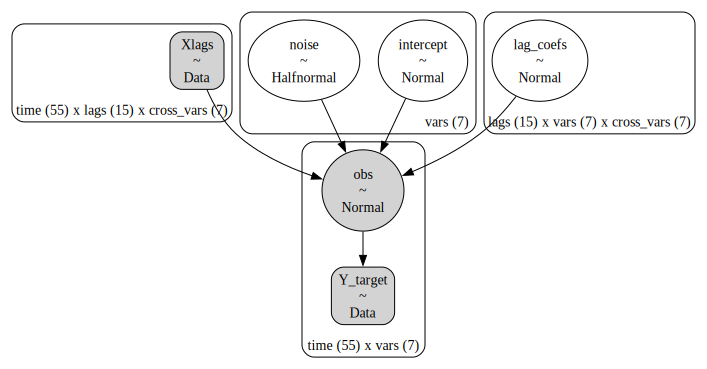

In [11]:
pm.model_to_graphviz(BVAR_model)

In [12]:
with BVAR_model:
    trace = pm.sample(
        draws=10000,
        tune=1000,
        chains=10,
        cores=10,
        target_accept=0.95,
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (10 chains in 10 jobs)
NUTS: [intercept, noise, lag_coefs]


Output()

Sampling 10 chains for 1_000 tune and 10_000 draw iterations (10_000 + 100_000 draws total) took 133 seconds.


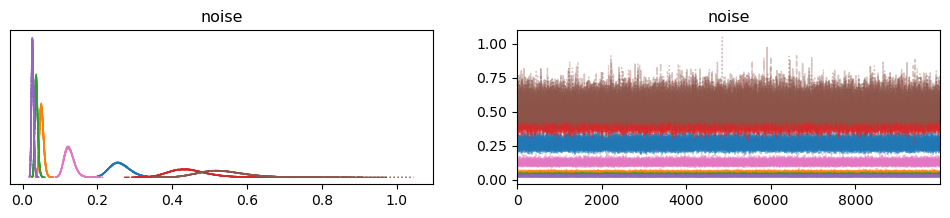

In [13]:
az.plot_trace(trace, var_names=["noise"]);

In [14]:
post = trace.posterior.stack(sample=("chain","draw"))
A = post["lag_coefs"].values   # (lags, vars, cross_vars, sample)
A = np.moveaxis(A, -1, 0)      # (sample, lags, K, K)

rng = np.random.default_rng(123)
idx = rng.choice(A.shape[0], size=min(200, A.shape[0]), replace=False)

max_mods = []
for i in idx:
    eigs = companion_eigs(A[i])
    max_mods.append(np.max(np.abs(eigs)))

np.mean(np.array(max_mods) < 1), np.quantile(max_mods, [0.5, 0.9, 0.99])

(np.float64(0.85), array([0.97388685, 1.00733842, 1.05158186]))

In [15]:
# --- 1) Shock setup ---
shock_var = "mil_delta"
shock_idx = vars_endog.index(shock_var)

# IMPORTANT:
# In your dataset (4a), mil_gdp is in % of GDP and mil_delta is in percentage points.
# Therefore: +1% of GDP shock = +1.0 (one percentage point)
shock_unstd = 1.0

shock_std = shock_unstd / data[shock_var].std()

print("Using shock_unstd =", shock_unstd, " (1% of GDP = 1pp)")
print("mil_delta std =", data[shock_var].std())

# --- 2) (Optional but recommended) filter stable draws ---
post = trace.posterior.stack(sample=("chain","draw"))
A = post["lag_coefs"].values          # (lags, K, K, sample)
A = np.moveaxis(A, -1, 0)             # (sample, lags, K, K)

max_mods = np.array([np.max(np.abs(companion_eigs(A[i]))) for i in range(A.shape[0])])
stable_idx = np.where(max_mods < 1)[0]

rng = np.random.default_rng(123)
use_pool = stable_idx if stable_idx.size > 0 else np.arange(A.shape[0])
use = rng.choice(use_pool, size=min(10000, use_pool.size), replace=False)

# --- 3) Compute IRFs in standardized units ---
H = 15
irfs_std = np.stack(
    [irf_from_A(A[i], shock_idx, horizons=H, shock_size=shock_std) for i in use],
    axis=0
)  # (draw, H+1, K)

# --- 4) Undo standardization so outputs are in original units ---
stds = data[vars_endog].std().to_numpy()
irfs = irfs_std * stds[None, None, :]

# --- 5) Sanity check: shocked var impact should equal shock_unstd ---
print(
    "Median impact response (mil_delta):",
    np.median(irfs[:, 0, shock_idx]),
    "| target:",
    shock_unstd
)

# --- 6) Convert log variables to percent for plotting (match 4b) ---
log_vars = {"log_gov_pc", "log_rgdp_pc", "log_tfp"}
irfs_plot = irfs.copy()
for j, name in enumerate(vars_endog):
    if name in log_vars:
        irfs_plot[:, :, j] = 100.0 * (np.exp(irfs_plot[:, :, j]) - 1.0)

Using shock_unstd = 1.0  (1% of GDP = 1pp)
mil_delta std = 0.34842088087092066
Median impact response (mil_delta): 0.9999999999999999 | target: 1.0


In [16]:
shock_idx = vars_endog.index("mil_delta")
print("Median impact mil_delta:", np.median(irfs[:, 0, shock_idx]))

Median impact mil_delta: 0.9999999999999999


In [17]:
print(data.describe().T[["mean","std","min","max"]])

                  mean        std        min         max
mil_delta    -0.037607   0.348421  -1.450743    1.332682
log_gov_pc   -5.494235   0.522387  -6.586382   -4.934825
log_rgdp_pc  -4.025783   0.473964  -5.104917   -3.503235
tbill         5.278852   3.903063  -0.496300   15.300000
log_tfp       2.085813   0.440996   1.074319    2.536313
def_gdp      -1.990516   2.061235  -6.788255    2.850095
debt_gdp     45.406170  27.789419  14.390000  115.042200


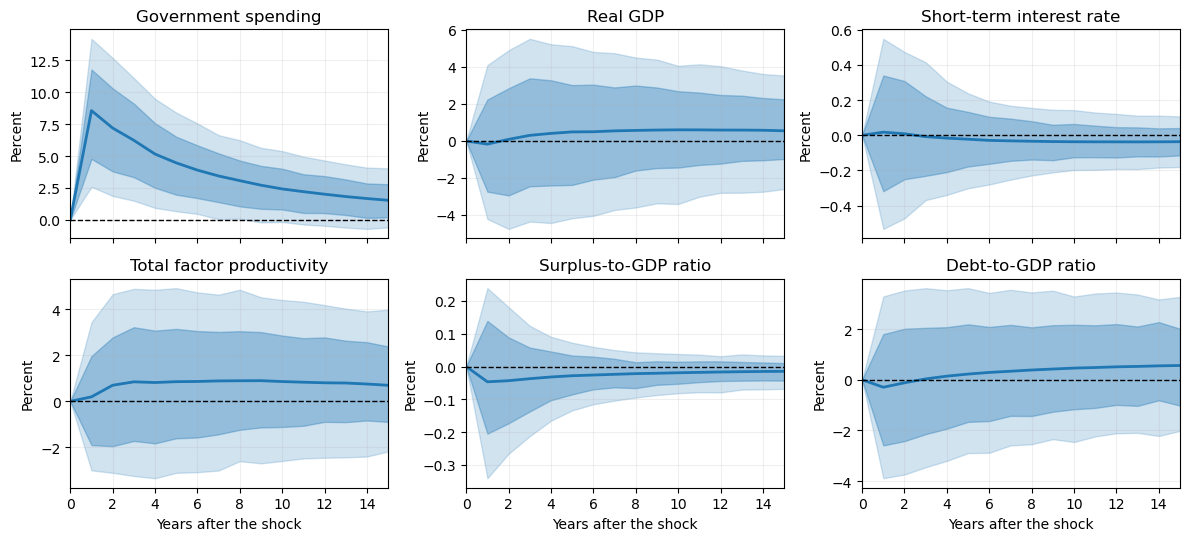

In [18]:
# --- log conversion EXACTLY like 4b ---
log_vars = {"log_gov_pc", "log_rgdp_pc", "log_tfp"}  # adjust names if needed

irfs_plot = irfs.copy()
for j, v in enumerate(vars_endog):
    if v in log_vars:
        irfs_plot[..., j] = 100.0 * (np.exp(irfs_plot[..., j]) - 1.0)


pretty = {
    "log_gov_pc": "Government spending",
    "log_rgdp_pc": "Real GDP",
    "tbill": "Short-term interest rate",
    "log_tfp": "Total factor productivity",
    "def_gdp": "Surplus-to-GDP ratio",
    "debt_gdp": "Debt-to-GDP ratio",
}

shock_var = "mil_delta"
resp_vars = [v for v in vars_endog if v != shock_var]


def hdi_bounds(y, prob):
    arr = xr.DataArray(y, dims=("draw", "horizon")).expand_dims(chain=[0])
    h = az.hdi(arr, hdi_prob=prob)
    if isinstance(h, xr.Dataset):
        h = next(iter(h.data_vars.values()))
    lo = h.sel(hdi="lower").values
    hi = h.sel(hdi="higher").values
    return lo, hi


h = np.arange(H + 1)
xmax = 15
xticks = np.arange(0, xmax + 1, 2)

n = len(resp_vars)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 6), sharex=True)
axes = np.atleast_1d(axes).ravel()

for ax, name in zip(axes, resp_vars):
    j = vars_endog.index(name)
    y = irfs_plot[:, :, j]

    med = np.median(y, axis=0)
    lo90, hi90 = hdi_bounds(y, 0.90)
    lo68, hi68 = hdi_bounds(y, 0.68)

    ax.fill_between(h, lo90, hi90, alpha=0.20, color="C0")
    ax.fill_between(h, lo68, hi68, alpha=0.35, color="C0")
    ax.plot(h, med, linewidth=2)
    ax.axhline(0, linestyle="--", linewidth=1, color="black")
    ax.set_xlim(0, xmax)

    ax.set_title(pretty.get(name, name))
    ax.set_ylabel("Percent")
    ax.grid(alpha=0.2)
    ax.set_xticks(xticks)

# turn off unused axes
for ax in axes[len(resp_vars):]:
    ax.axis("off")

# x-label only on bottom row
for ax in axes[-ncols:]:
    ax.set_xlabel("Years after the shock")

fig.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.savefig(Path.cwd().parent / "figures" / "Europe" / f"{country_iso}.png")
plt.show()